In [ ]:
# Import Libraries
import os
import gc
import shutil
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import warnings
warnings.filterwarnings("ignore")

# Data Visualization
from glob import glob
import xml.etree.ElementTree as xet
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import Image, display

# GPU
import torch
from numba import cuda

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = glob('/content/drive/MyDrive/Minor Project/LPdataset/google_images/**/*.xml', recursive=True)
print(len(path))


labels_dict = dict(filepath=[],xmin=[],xmax=[],ymin=[],ymax=[], plate_number=[])

for filename in path:

    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    plate_number = str(member_object.find('name').text)
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)

    labels_dict['filepath'].append(filename)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)
    labels_dict['plate_number'].append(plate_number)

440


In [ ]:
new_paths = glob('/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/*/*.xml')
print(len(new_paths))


new_labels_dict = dict(filepath=[],xmin=[],xmax=[],ymin=[],ymax=[], plate_number=[])

for filename in new_paths:

    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    plate_number = str(member_object.find('name').text)
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)

    new_labels_dict['filepath'].append(filename)
    new_labels_dict['xmin'].append(xmin)
    new_labels_dict['xmax'].append(xmax)
    new_labels_dict['ymin'].append(ymin)
    new_labels_dict['ymax'].append(ymax)
    new_labels_dict['plate_number'].append(plate_number)

608


In [ ]:
df = pd.DataFrame(labels_dict)
df.to_csv('labels.csv',index=False)
df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number
0,/content/drive/MyDrive/Minor Project/LPdataset...,335,453,313,347,KL05AK3300
1,/content/drive/MyDrive/Minor Project/LPdataset...,140,339,210,260,KA19TR02
2,/content/drive/MyDrive/Minor Project/LPdataset...,184,292,572,648,TN21AT0492
3,/content/drive/MyDrive/Minor Project/LPdataset...,185,374,290,339,MH20CS9817
4,/content/drive/MyDrive/Minor Project/LPdataset...,327,399,202,227,RJ27TC0530


In [ ]:
new_df = pd.DataFrame(new_labels_dict)
new_df.to_csv('new_labels.csv',index=False)
new_df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number
0,/content/drive/MyDrive/Minor Project/LPdataset...,78,173,304,328,WB08A4101
1,/content/drive/MyDrive/Minor Project/LPdataset...,159,223,111,142,WB26T6688
2,/content/drive/MyDrive/Minor Project/LPdataset...,97,185,265,287,WB02AJ4534
3,/content/drive/MyDrive/Minor Project/LPdataset...,73,166,231,252,WB06J2192
4,/content/drive/MyDrive/Minor Project/LPdataset...,93,169,368,392,WB36G6682


In [ ]:
# parsing
def parsing(path):
    parser = xet.parse(path).getroot()
    name = parser.find('filename').text
    filename = f'/content/drive/MyDrive/Minor Project/LPdataset/google_images/{name}'

    # width and height
    parser_size = parser.find('size')
    width = int(parser_size.find('width').text)
    height = int(parser_size.find('height').text)

    return filename, width, height

df[['filename','width','height']] = df['filepath'].apply(parsing).apply(pd.Series)
df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number,filename,width,height
0,/content/drive/MyDrive/Minor Project/LPdataset...,335,453,313,347,KL05AK3300,/content/drive/MyDrive/Minor Project/LPdataset...,480,480
1,/content/drive/MyDrive/Minor Project/LPdataset...,140,339,210,260,KA19TR02,/content/drive/MyDrive/Minor Project/LPdataset...,500,335
2,/content/drive/MyDrive/Minor Project/LPdataset...,184,292,572,648,TN21AT0492,/content/drive/MyDrive/Minor Project/LPdataset...,1280,853
3,/content/drive/MyDrive/Minor Project/LPdataset...,185,374,290,339,MH20CS9817,/content/drive/MyDrive/Minor Project/LPdataset...,588,476
4,/content/drive/MyDrive/Minor Project/LPdataset...,327,399,202,227,RJ27TC0530,/content/drive/MyDrive/Minor Project/LPdataset...,660,280


In [ ]:
# parsing
def newparsing(path):
    parser = xet.parse(path).getroot()
    name = parser.find('filename').text
    filename = f'/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/{name[:2]}/{name}'

    # width and height
    parser_size = parser.find('size')
    width = int(parser_size.find('width').text)
    height = int(parser_size.find('height').text)

    return filename, width, height

new_df[['filename','width','height']] = new_df['filepath'].apply(newparsing).apply(pd.Series)
new_df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number,filename,width,height
0,/content/drive/MyDrive/Minor Project/LPdataset...,78,173,304,328,WB08A4101,/content/drive/MyDrive/Minor Project/LPdataset...,272,570
1,/content/drive/MyDrive/Minor Project/LPdataset...,159,223,111,142,WB26T6688,/content/drive/MyDrive/Minor Project/LPdataset...,272,245
2,/content/drive/MyDrive/Minor Project/LPdataset...,97,185,265,287,WB02AJ4534,/content/drive/MyDrive/Minor Project/LPdataset...,272,363
3,/content/drive/MyDrive/Minor Project/LPdataset...,73,166,231,252,WB06J2192,/content/drive/MyDrive/Minor Project/LPdataset...,272,364
4,/content/drive/MyDrive/Minor Project/LPdataset...,93,169,368,392,WB36G6682,/content/drive/MyDrive/Minor Project/LPdataset...,272,590


In [ ]:
# center_x, center_y, width , height
df['center_x'] = (df['xmax'] + df['xmin'])/(2*df['width'])
df['center_y'] = (df['ymax'] + df['ymin'])/(2*df['height'])

df['bb_width'] = (df['xmax'] - df['xmin'])/df['width']
df['bb_height'] = (df['ymax'] - df['ymin'])/df['height']
df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/drive/MyDrive/Minor Project/LPdataset...,335,453,313,347,KL05AK3300,/content/drive/MyDrive/Minor Project/LPdataset...,480,480,0.820833,0.687500,0.245833,0.070833
1,/content/drive/MyDrive/Minor Project/LPdataset...,140,339,210,260,KA19TR02,/content/drive/MyDrive/Minor Project/LPdataset...,500,335,0.479000,0.701493,0.398000,0.149254
2,/content/drive/MyDrive/Minor Project/LPdataset...,184,292,572,648,TN21AT0492,/content/drive/MyDrive/Minor Project/LPdataset...,1280,853,0.185938,0.715123,0.084375,0.089097
3,/content/drive/MyDrive/Minor Project/LPdataset...,185,374,290,339,MH20CS9817,/content/drive/MyDrive/Minor Project/LPdataset...,588,476,0.475340,0.660714,0.321429,0.102941
4,/content/drive/MyDrive/Minor Project/LPdataset...,327,399,202,227,RJ27TC0530,/content/drive/MyDrive/Minor Project/LPdataset...,660,280,0.550000,0.766071,0.109091,0.089286


In [ ]:
# center_x, center_y, width , height
new_df['center_x'] = (new_df['xmax'] + new_df['xmin'])/(2*new_df['width'])
new_df['center_y'] = (new_df['ymax'] + new_df['ymin'])/(2*new_df['height'])

new_df['bb_width'] = (new_df['xmax'] - new_df['xmin'])/new_df['width']
new_df['bb_height'] = (new_df['ymax'] - new_df['ymin'])/new_df['height']
new_df.head()

,filepath,xmin,xmax,ymin,ymax,plate_number,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/drive/MyDrive/Minor Project/LPdataset...,78,173,304,328,WB08A4101,/content/drive/MyDrive/Minor Project/LPdataset...,272,570,0.461397,0.554386,0.349265,0.042105
1,/content/drive/MyDrive/Minor Project/LPdataset...,159,223,111,142,WB26T6688,/content/drive/MyDrive/Minor Project/LPdataset...,272,245,0.702206,0.516327,0.235294,0.126531
2,/content/drive/MyDrive/Minor Project/LPdataset...,97,185,265,287,WB02AJ4534,/content/drive/MyDrive/Minor Project/LPdataset...,272,363,0.518382,0.760331,0.323529,0.060606
3,/content/drive/MyDrive/Minor Project/LPdataset...,73,166,231,252,WB06J2192,/content/drive/MyDrive/Minor Project/LPdataset...,272,364,0.439338,0.663462,0.341912,0.057692
4,/content/drive/MyDrive/Minor Project/LPdataset...,93,169,368,392,WB36G6682,/content/drive/MyDrive/Minor Project/LPdataset...,272,590,0.481618,0.644068,0.279412,0.040678


In [ ]:
data = pd.concat([df,new_df]).sample(frac=1).reset_index(drop=True)
data.head()

,filepath,xmin,xmax,ymin,ymax,plate_number,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/drive/MyDrive/Minor Project/LPdataset...,259,729,200,347,HR99BJ6662,/content/drive/MyDrive/Minor Project/LPdataset...,919,532,0.537541,0.514098,0.511425,0.276316
1,/content/drive/MyDrive/Minor Project/LPdataset...,308,567,196,272,UP65CM21149,/content/drive/MyDrive/Minor Project/LPdataset...,1024,576,0.427246,0.406250,0.252930,0.131944
2,/content/drive/MyDrive/Minor Project/LPdataset...,91,182,206,228,DN09J0032,/content/drive/MyDrive/Minor Project/LPdataset...,270,505,0.505556,0.429703,0.337037,0.043564
3,/content/drive/MyDrive/Minor Project/LPdataset...,149,343,252,302,HR99EX6037,/content/drive/MyDrive/Minor Project/LPdataset...,500,416,0.492000,0.665865,0.388000,0.120192
4,/content/drive/MyDrive/Minor Project/LPdataset...,68,252,85,128,MH20CS9817,/content/drive/MyDrive/Minor Project/LPdataset...,404,211,0.396040,0.504739,0.455446,0.203791


In [ ]:
df_metadata = pd.DataFrame()
df_metadata = data.rename(columns={"filename": "image_path"})
df_metadata.head()

# Extract individual bbox coordinates
df_metadata["x1_bbox"] = df_metadata["xmin"]
df_metadata["y1_bbox"] = df_metadata["ymin"]
df_metadata["x2_bbox"] = df_metadata["xmax"]
df_metadata["y2_bbox"] = df_metadata["ymax"]
df_metadata["xmid"] = df_metadata["center_x"]
df_metadata["ymid"] = df_metadata["center_y"]
df_metadata = df_metadata.drop(columns=["filepath", "xmin", "xmax", "ymin", "ymax", "width", "height", "center_x", "center_y"])
df_metadata.head()

,plate_number,image_path,bb_width,bb_height,x1_bbox,y1_bbox,x2_bbox,y2_bbox,xmid,ymid
0,HR99BJ6662,/content/drive/MyDrive/Minor Project/LPdataset...,0.511425,0.276316,259,200,729,347,0.537541,0.514098
1,UP65CM21149,/content/drive/MyDrive/Minor Project/LPdataset...,0.252930,0.131944,308,196,567,272,0.427246,0.406250
2,DN09J0032,/content/drive/MyDrive/Minor Project/LPdataset...,0.337037,0.043564,91,206,182,228,0.505556,0.429703
3,HR99EX6037,/content/drive/MyDrive/Minor Project/LPdataset...,0.388000,0.120192,149,252,343,302,0.492000,0.665865
4,MH20CS9817,/content/drive/MyDrive/Minor Project/LPdataset...,0.455446,0.203791,68,85,252,128,0.396040,0.504739


In [ ]:
### split the data into train and test
df_train = data.iloc[:800]
df_test = data.iloc[850:]
df_val = data.iloc[800:850]
df_test.to_csv("df_test.csv", index=False)
df_train.to_csv("df_train.csv", index=False)
df_val.to_csv("df_val.csv", index=False)

In [ ]:
!mkdir -p "/content/drive/MyDrive/Minor Project/LPdataset/datasets/train"
!mkdir -p "/content/drive/MyDrive/Minor Project/LPdataset/datasets/val"
!mkdir -p "/content/drive/MyDrive/Minor Project/LPdataset/datasets/test"


In [ ]:
yaml_dir = '/content/drive/MyDrive/Minor Project/LPdataset/ultralytics/cfg/models/v3/'
os.makedirs(yaml_dir, exist_ok=True)  # Creates the directory if it doesn't exist

yaml_file_path = yaml_dir + 'yolov3-tiny.yaml'

with open(yaml_file_path, 'w') as file:
    file.write('''
    # Ultralytics YOLO 🚀, AGPL-3.0 license
# YOLOv3-tiny object detection model with P4-P5 outputs. For details see https://docs.ultralytics.com/models/yolov3

# Parameters
nc: 1  # number of classes
depth_multiple: 1.0  # model depth multiple
width_multiple: 1.0  # layer channel multiple

# YOLOv3-tiny backbone
backbone:
  # [from, number, module, args]
  [[-1, 1, Conv, [3, 3, 1]],  # 0
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 1-P1/2
   [-1, 1, Conv, [3, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 3-P2/4
   [-1, 1, Conv, [3, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 5-P3/8
   [-1, 1, Conv, [128, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 7-P4/16
   [-1, 1, Conv, [256, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 9-P5/32
   [-1, 1, Conv, [512, 3, 1]],
   [-1, 1, nn.ZeroPad2d, [[0, 1, 0, 1]]],  # 11
   [-1, 1, nn.MaxPool2d, [2, 1, 0]],  # 12
  ]

# YOLOv3-tiny head
head:
  [[-1, 1, Conv, [1024, 3, 1]],
   [-1, 1, Conv, [256, 1, 1]],
   [-1, 1, Conv, [512, 3, 1]],  # 15 (P5/32-large)

   [-2, 1, Conv, [128, 1, 1]],
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 8], 1, Concat, [1]],  # cat backbone P4
   [-1, 1, Conv, [256, 1, 1]],  # 19 (P4/16-medium)

   [[19, 15], 1, Detect, [nc]],  # Detect(P4, P5)
  ]

    ''')


# Verify
with open(yaml_file_path, 'r') as file:
    modified_content = file.read()
    print(modified_content)


    # Ultralytics YOLO 🚀, AGPL-3.0 license
# YOLOv3-tiny object detection model with P4-P5 outputs. For details see https://docs.ultralytics.com/models/yolov3

# Parameters
nc: 1  # number of classes
depth_multiple: 1.0  # model depth multiple
width_multiple: 1.0  # layer channel multiple

# YOLOv3-tiny backbone
backbone:
  # [from, number, module, args]
  [[-1, 1, Conv, [3, 3, 1]],  # 0
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 1-P1/2
   [-1, 1, Conv, [3, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 3-P2/4
   [-1, 1, Conv, [3, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 5-P3/8
   [-1, 1, Conv, [128, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 7-P4/16
   [-1, 1, Conv, [256, 3, 1]],
   [-1, 1, nn.MaxPool2d, [2, 2, 0]],  # 9-P5/32
   [-1, 1, Conv, [512, 3, 1]],
   [-1, 1, nn.ZeroPad2d, [[0, 1, 0, 1]]],  # 11
   [-1, 1, nn.MaxPool2d, [2, 1, 0]],  # 12
  ]

# YOLOv3-tiny head
head:
  [[-1, 1, Conv, [1024, 3, 1]],
   [-1, 1, Conv, [256, 1, 1]],
   [-1, 1, Conv, [512, 3, 1]],  # 15

In [ ]:
train_folder = '/content/drive/MyDrive/Minor Project/LPdataset/datasets/train'

values = df_train[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    try:
        image_name = os.path.split(fname)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(train_folder,image_name)
        dst_label_file = os.path.join(train_folder,txt_name+'.txt')

        # copy each image into the folder
        shutil.copy(fname,dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file,mode='w') as f:
            f.write(label_txt)

            f.close()
    except:
        print(fname)

/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/NL/NL1.jpg


In [ ]:
test_folder = '/content/drive/MyDrive/Minor Project/LPdataset/datasets/test'

values = df_test[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    try:
        image_name = os.path.split(fname)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(test_folder,image_name)
        dst_label_file = os.path.join(test_folder,txt_name+'.txt')

        # copy each image into the folder
        shutil.copy(fname,dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file,mode='w') as f:
            f.write(label_txt)

            f.close()
    except:
        print(fname)

In [ ]:
val_folder = '/content/drive/MyDrive/Minor Project/LPdataset/datasets/val'

values = df_val[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    try:
        image_name = os.path.split(fname)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(val_folder,image_name)
        dst_label_file = os.path.join(val_folder,txt_name+'.txt')

        # copy each image into the folder
        shutil.copy(fname,dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file,mode='w') as f:
            f.write(label_txt)

            f.close()
    except:
        print(fname)

/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/MH/MH5.jpg


In [ ]:
%%writefile "/content/drive/MyDrive/Minor Project/LPdataset/custom_dataset.yaml"
train: "/content/drive/MyDrive/Minor Project/LPdataset/datasets/train"
val: "/content/drive/MyDrive/Minor Project/LPdataset/datasets/val"
test: "/content/drive/MyDrive/Minor Project/LPdataset/datasets/test"

nc: 1

names: [
    'license_plate'
]


Writing /content/drive/MyDrive/Minor Project/LPdataset/dataset.yaml


In [ ]:
!pip install gputil
from GPUtil import showUtilization as gpu_usage

def free_gpu_cache():
    print("Initial GPU Usage")
    gpu_usage()

    torch.cuda.empty_cache()

    cuda.select_device(0)
    cuda.close()
    cuda.select_device(0)

    print("GPU Usage after emptying the cache")
    gpu_usage()

free_gpu_cache()

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% |  1% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  3% |  1% |


In [ ]:
!wandb disabled
!yolo train model=yolov3-tinyu.pt data="/content/drive/MyDrive/Minor Project/LPdataset/custom_dataset.yaml" epochs=100 verbose=True batch=32


W&B disabled.
Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov3-tinyu.pt, data=/content/drive/MyDrive/Minor Project/LPdataset/custom_dataset.yaml, epochs=100, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, 

In [ ]:
!cp '/content/runs/train/exp/weights/best.pt' '/content/drive/MyDrive/Minor Project/'

In [ ]:
training_results = pd.read_csv("/content/drive/MyDrive/Minor Project/train4/results.csv")
list_column = [col.strip() for col in training_results.columns]
training_results.columns = list_column

training_results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,32.5155,1.55133,4.66220,1.27439,0.83615,0.84176,0.89199,0.56208,1.20117,4.13187,1.09803,0.000480,0.000480,0.000480
1,2,53.4383,1.07724,0.76632,1.02002,0.87163,0.88660,0.93349,0.64315,1.10408,0.84973,1.10187,0.000970,0.000970,0.000970
2,3,73.8761,1.06027,0.72462,1.03425,0.84090,0.81735,0.86154,0.52777,1.23809,0.99756,1.12147,0.001451,0.001451,0.001451
3,4,94.1526,1.04902,0.69564,1.01884,0.93475,0.93814,0.97371,0.68467,1.09180,0.68874,1.01734,0.001921,0.001921,0.001921
4,5,115.7790,0.97371,0.64721,0.99329,0.93782,0.93300,0.96056,0.69646,0.98441,0.70351,1.00072,0.001921,0.001921,0.001921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,2008.6900,0.47190,0.28061,0.82553,1.00000,0.98835,0.99407,0.87824,0.57203,0.31937,0.83441,0.000119,0.000119,0.000119
96,97,2028.6500,0.46984,0.28326,0.83135,1.00000,0.98941,0.99424,0.87805,0.58102,0.32654,0.83650,0.000099,0.000099,0.000099
97,98,2047.8600,0.46709,0.28091,0.83433,0.99950,0.98969,0.99415,0.88417,0.57917,0.31950,0.83473,0.000079,0.000079,0.000079
98,99,2067.7900,0.44146,0.27628,0.82256,0.99944,0.98969,0.99415,0.88111,0.57263,0.31848,0.83441,0.000060,0.000060,0.000060


In [ ]:
# Training and Validation Loss

# Create Subplot
fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=["Localization Loss", "Classification Loss"],
)

# Configuration Plot
class PlotCFG:
    marker_size = 6.5
    line_size = 2
    train_color = "#1e3772"
    valid_color = "#2788f9"

loss_list = ["box_loss", "cls_loss"]
for i, loss in enumerate(loss_list):
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["train/{}".format(loss)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.train_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.train_color, width=PlotCFG.line_size),
            name="Training"
        ), row=1, col=i+1
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["val/{}".format(loss)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.valid_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.valid_color, width=PlotCFG.line_size),
            name="Validation"
        ), row=1, col=i+1
    )

# Update Axes
ticklabels = ["Box Loss", "Cls Loss"]
for i, ticklabel in enumerate(ticklabels):
    fig.update_xaxes(title="Epochs", linecolor="Black", ticks="outside", row=1, col=i+1)
    fig.update_yaxes(title=ticklabel, linecolor="Black", ticks="outside", row=1, col=i+1)

# Update Layout
fig.update_layout(
    title="Training and Validation Loss", title_x=0.5, font_family="Trebuchet MS",
    width=950, height=350,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

fig.show(iframe_connected=True)

In [ ]:
# Validation Metrics

# Create Subplot
subplot_titles = ["Precision", "Recall"]
fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=subplot_titles,
)

# Configuration Plot
class PlotCFG:
    marker_size = 7
    line_size = 2
    train_color = "#1e3772"
    valid_color = "#2788f9"

metrics = ["precision", "recall"]
for i, metric in enumerate(metrics):
    # Plot
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["metrics/{}(B)".format(metric)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.valid_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.valid_color, width=PlotCFG.line_size),
            name="Validation"
        ), row=(i//2)+1, col=(i%2)+1
    )

    # Update Axes
    fig.update_xaxes(title="Epochs", linecolor="Black", ticks="outside", row=(i//2)+1, col=(i%2)+1)
    fig.update_yaxes(title=subplot_titles[i], linecolor="Black", ticks="outside", row=(i//2)+1, col=(i%2)+1)

# Update Layout
fig.update_layout(
    title="Validation Metrics", title_x=0.5, font_family="Trebuchet MS",
    width=950, height=300,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

# Show
fig.show(iframe_connected=True)

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
!yolo val model="/content/drive/MyDrive/Minor Project/train4/weights/best.pt" data="/content/drive/MyDrive/Minor Project/LPdataset/custom_dataset.yaml" split="test"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

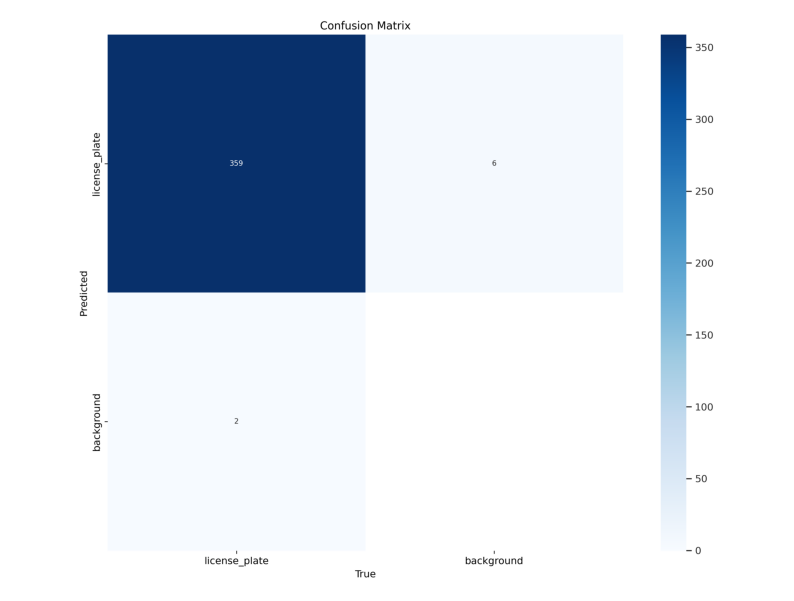

In [ ]:
fig = plt.figure(figsize=(10, 9))
cm_img = mpimg.imread("/content/drive/MyDrive/Minor Project/val3/confusion_matrix.png")
plt.imshow(cm_img)
plt.axis("off")
fig.show()

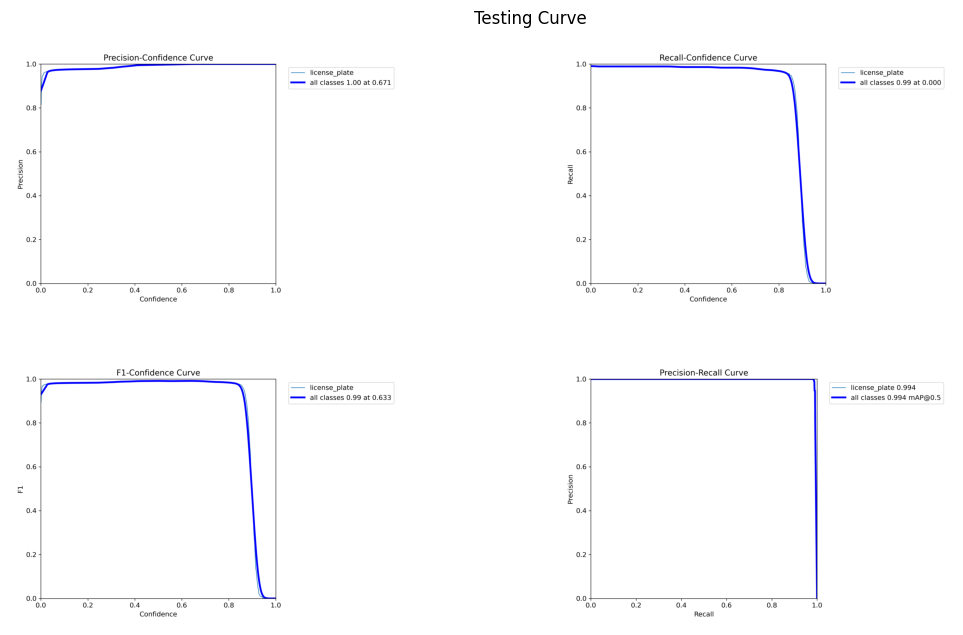

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
curve_list = ["P_curve", "R_curve", "F1_curve", "PR_curve"]
for i, curve in enumerate(curve_list):
    curve_path = "/content/drive/MyDrive/Minor Project/val3/{}.png".format(curve)
    curve_img = mpimg.imread(curve_path)
    axs[i//2, i%2].imshow(curve_img)
    axs[i//2, i%2].axis('off')

# Title
plt.suptitle("Testing Curve", x=0.55, y=0.93)

# Show
plt.show()

In [ ]:
df_results =df_test[["filename", "plate_number", "xmin", "ymin", "xmax", "ymax"]]
df_results = df_results.rename(columns={"filename": "image_path", "xmin": "x1_bbox", "ymin": "y1_bbox", "xmax": "x2_bbox", "ymax": "y2_bbox"})
df_results = df_results.reset_index(drop=True)
df_results

,image_path,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox
0,/content/drive/MyDrive/Minor Project/LPdataset...,TN19Q0835,88,279,169,297
1,/content/drive/MyDrive/Minor Project/LPdataset...,MH03BS7778,297,422,558,493
2,/content/drive/MyDrive/Minor Project/LPdataset...,AS04P4549,95,219,148,233
3,/content/drive/MyDrive/Minor Project/LPdataset...,KL60N5344,51,200,185,231
4,/content/drive/MyDrive/Minor Project/LPdataset...,HR26DK0830,342,241,492,290
...,...,...,...,...,...,...
193,/content/drive/MyDrive/Minor Project/LPdataset...,OD11P6123,99,130,165,148
194,/content/drive/MyDrive/Minor Project/LPdataset...,ML05C5389,49,222,106,236
195,/content/drive/MyDrive/Minor Project/LPdataset...,JH10BV1496,100,276,182,293
196,/content/drive/MyDrive/Minor Project/LPdataset...,KL7BZ99,176,214,564,322


In [ ]:
import os
from ultralytics import YOLO

yolo_model = YOLO('/content/drive/MyDrive/Minor Project/train4/weights/best.pt')

all_box_list = []
all_conf_list = []

# Iterate over all image paths, ensuring the correct order
for img_path in df_results["image_path"]:
    if not os.path.exists(img_path):
        all_box_list.append(None)  # Append None for missing images
        all_conf_list.append(None)
        continue  # Skip to the next image

    bbox_result = yolo_model.predict(img_path, verbose=False)[0]

    boxes = bbox_result.boxes
    box_list = []
    conf_list = []
    for box in boxes:
        box_data = box.data[0][:4]
        box_data = [int(x) for x in box_data]
        conf = round(float(box.conf), 2)
        if conf >= 0.5:
            box_list.append(box_data)
            conf_list.append(conf)

    all_box_list.append(box_list)
    all_conf_list.append(conf_list)




In [ ]:
df_results["pred_bbox"] = all_box_list
df_results["confidence"] = all_conf_list
df_results

,image_path,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox,pred_bbox,confidence
0,/content/drive/MyDrive/Minor Project/LPdataset...,TN19Q0835,88,279,169,297,"[[87, 278, 169, 297]]",[0.89]
1,/content/drive/MyDrive/Minor Project/LPdataset...,MH03BS7778,297,422,558,493,"[[300, 417, 552, 488]]",[0.9]
2,/content/drive/MyDrive/Minor Project/LPdataset...,AS04P4549,95,219,148,233,"[[96, 219, 147, 232]]",[0.86]
3,/content/drive/MyDrive/Minor Project/LPdataset...,KL60N5344,51,200,185,231,"[[51, 199, 185, 230]]",[0.88]
4,/content/drive/MyDrive/Minor Project/LPdataset...,HR26DK0830,342,241,492,290,"[[341, 241, 490, 288]]",[0.91]
...,...,...,...,...,...,...,...,...
193,/content/drive/MyDrive/Minor Project/LPdataset...,OD11P6123,99,130,165,148,"[[100, 129, 164, 147]]",[0.89]
194,/content/drive/MyDrive/Minor Project/LPdataset...,ML05C5389,49,222,106,236,"[[49, 222, 106, 236]]",[0.89]
195,/content/drive/MyDrive/Minor Project/LPdataset...,JH10BV1496,100,276,182,293,"[[100, 276, 181, 293]]",[0.89]
196,/content/drive/MyDrive/Minor Project/LPdataset...,KL7BZ99,176,214,564,322,"[[156, 213, 557, 326]]",[0.83]


/content/drive/MyDrive/Minor Project/LPdataset/google_images/422aaf6f-dd4a-450f-ac6b-65966ab512d0___1431956d1446017445-number-plates-merchandise-canvas-ink-gurgaon-edit-closed-thumb_img_4418_1024.jpg.jpeg


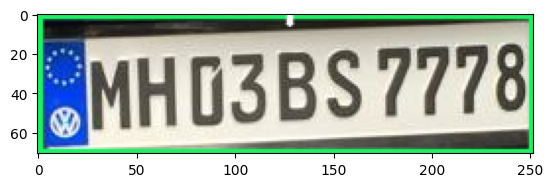

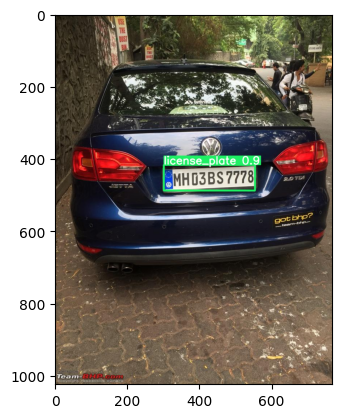

/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/AS/AS18.jpg


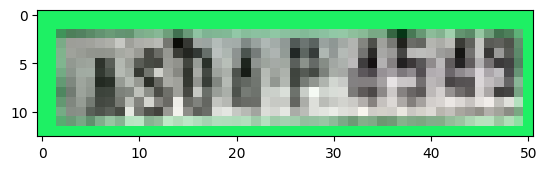

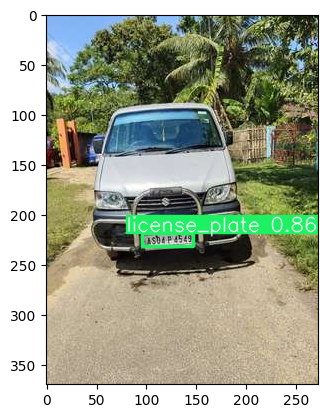

/content/drive/MyDrive/Minor Project/LPdataset/google_images/c48f8704-bc40-462a-a595-445b2f2e63fe___new_77cca4b6f3864b3928824a030ba101d2.jpg.jpeg


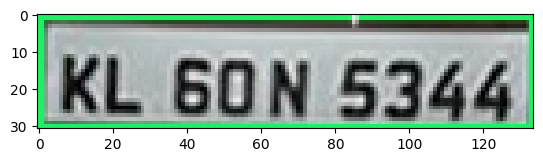

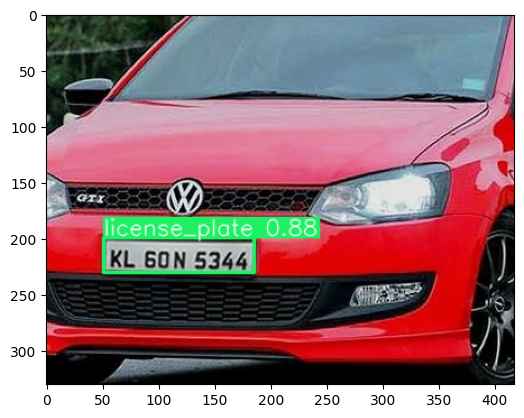

/content/drive/MyDrive/Minor Project/LPdataset/google_images/car-wbs-HRDK0830_00000.jpeg


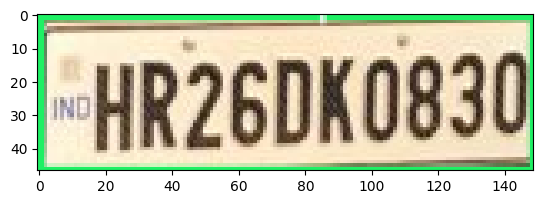

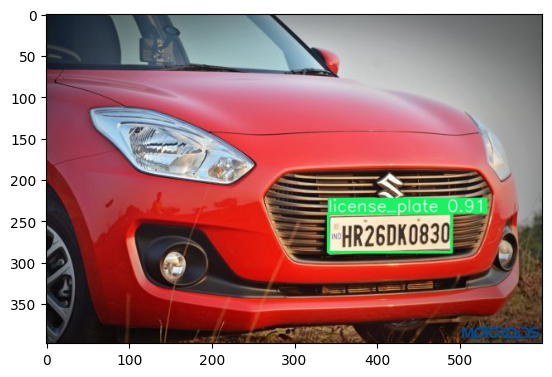

/content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/MH/MH19.jpg


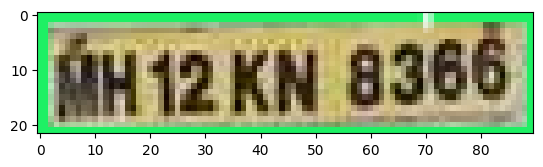

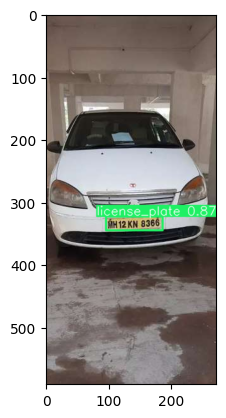

In [ ]:
from ultralytics.utils.plotting import Annotator

def show_plate_detection(idx):
    # Original Image
    ori_path = df_results["image_path"][idx]
    print(ori_path)
    ori_image = cv2.imread(ori_path)
    ori_image = cv2.cvtColor(ori_image, cv2.COLOR_BGR2RGB)

    # Annotate Box
    annotator = Annotator(ori_image)
    boxes = df_results["pred_bbox"][idx]
    confs = df_results["confidence"][idx]
    for i, box in enumerate(boxes):
        annotator.box_label(box=box, label="license_plate " + (str(confs[i])), color=(30, 240, 100))

        # Get Plate Object
        x1, y1, x2, y2 = box
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        roi = ori_image[y1:y2, x1:x2]
        plt.imshow(roi)
        plt.show()

    # Show Image
    frame = annotator.result()
    plt.imshow(frame)
    plt.show()

idxs = [1, 2, 3, 4, 5]
for idx in idxs:
    show_plate_detection(idx)

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.6/286.6 kB 29.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import easyocr

import numpy as np
from tqdm import tqdm

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

def get_text_easyocr(idx):
    ori_path = df_results["image_path"][idx]

    if not os.path.exists(ori_path):
        print(f"Skipping missing image: {ori_path}")
        return [""]  # Placeholder to maintain DataFrame length

    ori_image = cv2.imread(ori_path)

    if ori_image is None:
        print(f"Error reading image: {ori_path}")
        return [""]

    ori_image = cv2.cvtColor(ori_image, cv2.COLOR_BGR2RGB)

    text_list = []
    bboxs = df_results["pred_bbox"][idx]

    if bboxs is None or not isinstance(bboxs, list):
        print(f"No bounding boxes for {ori_path}")
        return [""]

    for bbox in bboxs:
        try:
            # Crop image using bounding box
            crop_image = ori_image[bbox[1]:bbox[3], bbox[0]:bbox[2]]

            # Extract text from the cropped image
            result = reader.readtext(crop_image)
            text_output = ' '.join([res[1] for res in result]).strip()

            if len(text_output) > 0:
                # Clean extracted text
                clean_text = re.sub(r"[ ·:-]", "", text_output)
                clean_text = clean_text.replace("O", "0").replace("I", "1").upper()
                text_list.append(clean_text)

        except Exception as e:
            print(f"Error processing bbox {bbox} in {ori_path}: {e}")

    return text_list if text_list else [""]




In [ ]:
!pip install onnxruntime
import re
idxs = list(np.arange(0, len(df_results)))  # Ensure correct index range

text_results = []
for idx in tqdm(idxs):
    text_results.append(get_text_easyocr(idx))  # Append results while handling errors

df_results["pred_plate_number"] = text_results

df_results  # Display DataFrame

 14%|█▎        | 27/198 [00:00<00:05, 33.12it/s]

Skipping missing image: /content/drive/MyDrive/Minor Project/LPdataset/State-wise_OLX/NL/NL1.jpg


100%|██████████| 198/198 [00:05<00:00, 36.19it/s]


,image_path,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox,pred_bbox,confidence,pred_plate_number
0,/content/drive/MyDrive/Minor Project/LPdataset...,TN19Q0835,88,279,169,297,"[[87, 278, 169, 297]]",[0.89],[1N1900835]
1,/content/drive/MyDrive/Minor Project/LPdataset...,MH03BS7778,297,422,558,493,"[[300, 417, 552, 488]]",[0.9],[MH03BS7778]
2,/content/drive/MyDrive/Minor Project/LPdataset...,AS04P4549,95,219,148,233,"[[96, 219, 147, 232]]",[0.86],[1SB4F4I49]
3,/content/drive/MyDrive/Minor Project/LPdataset...,KL60N5344,51,200,185,231,"[[51, 199, 185, 230]]",[0.88],[KLG0N5344]
4,/content/drive/MyDrive/Minor Project/LPdataset...,HR26DK0830,342,241,492,290,"[[341, 241, 490, 288]]",[0.91],[HR2GDK0830]
...,...,...,...,...,...,...,...,...,...
193,/content/drive/MyDrive/Minor Project/LPdataset...,OD11P6123,99,130,165,148,"[[100, 129, 164, 147]]",[0.89],[0D1LP6423]
194,/content/drive/MyDrive/Minor Project/LPdataset...,ML05C5389,49,222,106,236,"[[49, 222, 106, 236]]",[0.89],[WL0SCS200]
195,/content/drive/MyDrive/Minor Project/LPdataset...,JH10BV1496,100,276,182,293,"[[100, 276, 181, 293]]",[0.89],[JH108V1496]
196,/content/drive/MyDrive/Minor Project/LPdataset...,KL7BZ99,176,214,564,322,"[[156, 213, 557, 326]]",[0.83],[KL7BZ99]


In [1]:
%matplotlib inline
idxs = [0, 1, 2, 3, 4, 5, 6]
for idx in idxs:
    show_plate_detection(idx)
    text_ocr = get_text_easyocr(idx)
    print(text_ocr)

NameError: name 'show_plate_detection' is not defined